###Asia Logistics Performance & Supply Chain Insights: Analyzing Efficiency and Profitability

In [ ]:
import pandas as pd
import numpy as np

# Memuat dataset
file_path = 'ASIA.xlsx'
df = pd.read_excel(file_path)

# Membuat salinan data agar data asli tetap utuh (Best Practice)
df_clean = df.copy()

print("Step 0 Berhasil: Data siap dibersihkan. Jumlah baris awal:", len(df_clean))

Step 0 Berhasil: Data siap dibersihkan. Jumlah baris awal: 31112


In [ ]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-03-02 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,2,1,95.180000,288.420013,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 10:42,First Class
4,TRANSFER,2,1,68.430000,285.140015,Late delivery,1,73,Sporting Goods,Miami,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 10:21,First Class


###Step 1: Keamanan & Perampingan Data

In [ ]:
# Daftar kolom yang akan dihapus
kolom_dihapus = [
    'Order Zipcode',
    'Product Description',
    'Customer Password',
    'Customer Email',
    'Product Image'
]

# Menghapus kolom
df_clean = df_clean.drop(columns=kolom_dihapus)

print("Step 1 Berhasil: Kolom sensitif dan kosong telah dihapus.")
print("Sisa kolom saat ini:", len(df_clean.columns))

Step 1 Berhasil: Kolom sensitif dan kosong telah dihapus.
Sisa kolom saat ini: 48


###Step 2: Standardisasi Tipe Data

In [ ]:
# Mengonversi format tanggal menjadi datetime yang standar
# Parameter format='mixed' sangat berguna di pandas versi baru untuk mengatasi format tanggal yang berbeda-beda
df_clean['order date (DateOrders)'] = pd.to_datetime(df_clean['order date (DateOrders)'], format='mixed')
df_clean['shipping date (DateOrders)'] = pd.to_datetime(df_clean['shipping date (DateOrders)'], format='mixed')

# Memastikan tipe data finansial sudah benar (float)
df_clean['Sales'] = df_clean['Sales'].astype(float)
df_clean['Order Profit Per Order'] = df_clean['Order Profit Per Order'].astype(float)

print("Step 2 Berhasil: Format tanggal telah diseragamkan.")

Step 2 Berhasil: Format tanggal telah diseragamkan.


###Step 3: Penanganan Data Hilang & Anomali

In [ ]:
# Mengisi missing values pada nama belakang dengan 'Unknown'
df_clean['Customer Lname'] = df_clean['Customer Lname'].fillna('Unknown')

# Menghapus baris anomali dimana nilai Sales <= 0
df_clean = df_clean[df_clean['Sales'] > 0]

print("Step 3 Berhasil: Missing values diatasi dan anomali Sales difilter.")

Step 3 Berhasil: Missing values diatasi dan anomali Sales difilter.


###Step 4: Validasi Logika Bisnis

In [ ]:
# 1. Sinkronisasi: Jika statusnya 'Late delivery', paksakan nilai risk menjadi 1
kondisi_terlambat = df_clean['Delivery Status'] == 'Late delivery'
df_clean.loc[kondisi_terlambat, 'Late_delivery_risk'] = 1

# 2. Integritas Waktu: Menyaring data agar hanya menyisakan pesanan dengan alur waktu yang logis
# (Tanggal kirim HARUS sama dengan atau setelah tanggal order)
df_clean = df_clean[df_clean['shipping date (DateOrders)'] >= df_clean['order date (DateOrders)']]

print("Step 4 Berhasil: Logika bisnis dan integritas alur waktu telah divalidasi.")

Step 4 Berhasil: Logika bisnis dan integritas alur waktu telah divalidasi.


###Step 5: Rekayasa Fitur / Feature Engineering

In [ ]:
# Metrik Operasional: Menghitung selisih hari pengiriman riil vs jadwal
df_clean['Shipping_Gap'] = df_clean['Days for shipping (real)'] - df_clean['Days for shipment (scheduled)']

# Metrik Finansial: Menghitung Profit Margin (dalam persentase desimal)
df_clean['Profit_Margin'] = df_clean['Order Profit Per Order'] / df_clean['Sales']

print("Step 5 Berhasil: Metrik 'Shipping_Gap' dan 'Profit_Margin' berhasil dibuat.")
print("\n=== PEMBERSIHAN SELESAI ===")
print(f"Jumlah baris akhir yang siap dianalisis: {len(df_clean)}")

Step 5 Berhasil: Metrik 'Shipping_Gap' dan 'Profit_Margin' berhasil dibuat.

=== PEMBERSIHAN SELESAI ===
Jumlah baris akhir yang siap dianalisis: 26713


###Analisis Metrik Finansial

In [ ]:
# --- 1. RINGKASAN FINANSIAL ---
print("=== 1. RINGKASAN PERFORMA FINANSIAL ===")

# Menghitung total dan rata-rata
total_sales = df_clean['Sales'].sum()
total_profit = df_clean['Order Profit Per Order'].sum()
rata_rata_margin = df_clean['Profit_Margin'].mean() * 100 # Dijadikan persentase

print(f"Total Pendapatan (Sales)   : ${total_sales:,.2f}")
print(f"Total Keuntungan (Profit)  : ${total_profit:,.2f}")
print(f"Rata-rata Profit Margin    : {rata_rata_margin:.2f}%")

# Menampilkan statistik deskriptif khusus kolom finansial
print("\nDetail Statistik Finansial:")
print(df_clean[['Sales', 'Order Profit Per Order', 'Profit_Margin']].describe())

=== 1. RINGKASAN PERFORMA FINANSIAL ===
Total Pendapatan (Sales)   : $5,393,625.40
Total Keuntungan (Profit)  : $574,285.59
Rata-rata Profit Margin    : 10.59%

Detail Statistik Finansial:
              Sales  Order Profit Per Order  Profit_Margin
count  26713.000000            26713.000000   26713.000000
mean     201.910133               21.498356       0.105949
std      140.396974              104.693398       0.420586
min        9.990000            -2592.000000      -2.749995
25%      111.959999                5.370000       0.061491
50%      199.919998               29.160000       0.240685
75%      299.950012               64.110001       0.333026
max     1500.000000              684.000000       0.500038


###Analisis Performa Logistik & Operasional

In [ ]:
# --- 2. RINGKASAN OPERASIONAL (LOGISTIK) ---
print("=== 2. PERFORMA LOGISTIK & PENGIRIMAN ===")

# Menghitung rata-rata keterlambatan dan rasio risiko
rata_rata_gap = df_clean['Shipping_Gap'].mean()
rasio_terlambat = (df_clean['Late_delivery_risk'].sum() / len(df_clean)) * 100

print(f"Rata-rata Selisih Waktu Pengiriman : {rata_rata_gap:.2f} hari (Positif = Terlambat, Negatif = Lebih Cepat)")
print(f"Persentase Pesanan Terlambat       : {rasio_terlambat:.2f}%\n")

# Melihat distribusi metrik operasional
print("Detail Statistik Operasional:")
print(df_clean[['Days for shipment (scheduled)', 'Days for shipping (real)', 'Shipping_Gap']].describe())

=== 2. PERFORMA LOGISTIK & PENGIRIMAN ===
Rata-rata Selisih Waktu Pengiriman : 0.53 hari (Positif = Terlambat, Negatif = Lebih Cepat)
Persentase Pesanan Terlambat       : 54.48%

Detail Statistik Operasional:
       Days for shipment (scheduled)  Days for shipping (real)  Shipping_Gap
count                   26713.000000              26713.000000  26713.000000
mean                        2.869165                  3.395613      0.526448
std                         1.399414                  1.618430      1.494694
min                         0.000000                  0.000000     -2.000000
25%                         2.000000                  2.000000      0.000000
50%                         4.000000                  3.000000      1.000000
75%                         4.000000                  5.000000      1.000000
max                         4.000000                  6.000000      4.000000


###Analisis Pasar Regional Asia

In [ ]:
# --- 3. ANALISIS PASAR REGIONAL ASIA ---
print("=== 3. TOP 5 NEGARA DENGAN PENJUALAN TERTINGGI ===")

# Mengelompokkan data berdasarkan Negara Tujuan (Order Country)
top_5_negara = df_clean.groupby('Order Country')[['Sales', 'Order Profit Per Order']].sum()

# Mengurutkan dari Sales tertinggi dan mengambil 5 teratas
top_5_negara = top_5_negara.sort_values(by='Sales', ascending=False).head(5)

# Menambahkan kolom Margin untuk setiap negara
top_5_negara['Profit Margin (%)'] = (top_5_negara['Order Profit Per Order'] / top_5_negara['Sales']) * 100

print(top_5_negara)

=== 3. TOP 5 NEGARA DENGAN PENJUALAN TERTINGGI ===
                      Sales  Order Profit Per Order  Profit Margin (%)
Order Country                                                         
China          1.005110e+06           105881.820439          10.534347
India          8.447974e+05            85822.209955          10.158911
Indonesia      7.300515e+05            82545.649765          11.306825
Turquía        5.556520e+05            61744.329883          11.112050
Filipinas      3.634450e+05            40112.759850          11.036818


###KPI Summary

In [ ]:
# --- SEL: RINGKASAN KPI UNTUK TABLEAU ---
print("--- STRATEGIC KPI SUMMARY ---")
print(f"1. Late Delivery Rate     : {df_clean['Late_delivery_risk'].mean()*100:.2f}%")
print(f"2. Avg Profit Margin      : {df_clean['Profit_Margin'].mean()*100:.2f}%")
print(f"3. Avg Shipping Gap       : {df_clean['Shipping_Gap'].mean():.2f} Days")
print(f"4. Total Asian Revenue    : ${df_clean['Sales'].sum():,.0f}")

--- STRATEGIC KPI SUMMARY ---
1. Late Delivery Rate     : 54.48%
2. Avg Profit Margin      : 10.59%
3. Avg Shipping Gap       : 0.53 Days
4. Total Asian Revenue    : $5,393,625


/tmp/ipython-input-613/2036576549.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Profit Margin (%)', y='Order Country', data=top_5_margin, ax=axes[1, 0], palette='viridis')


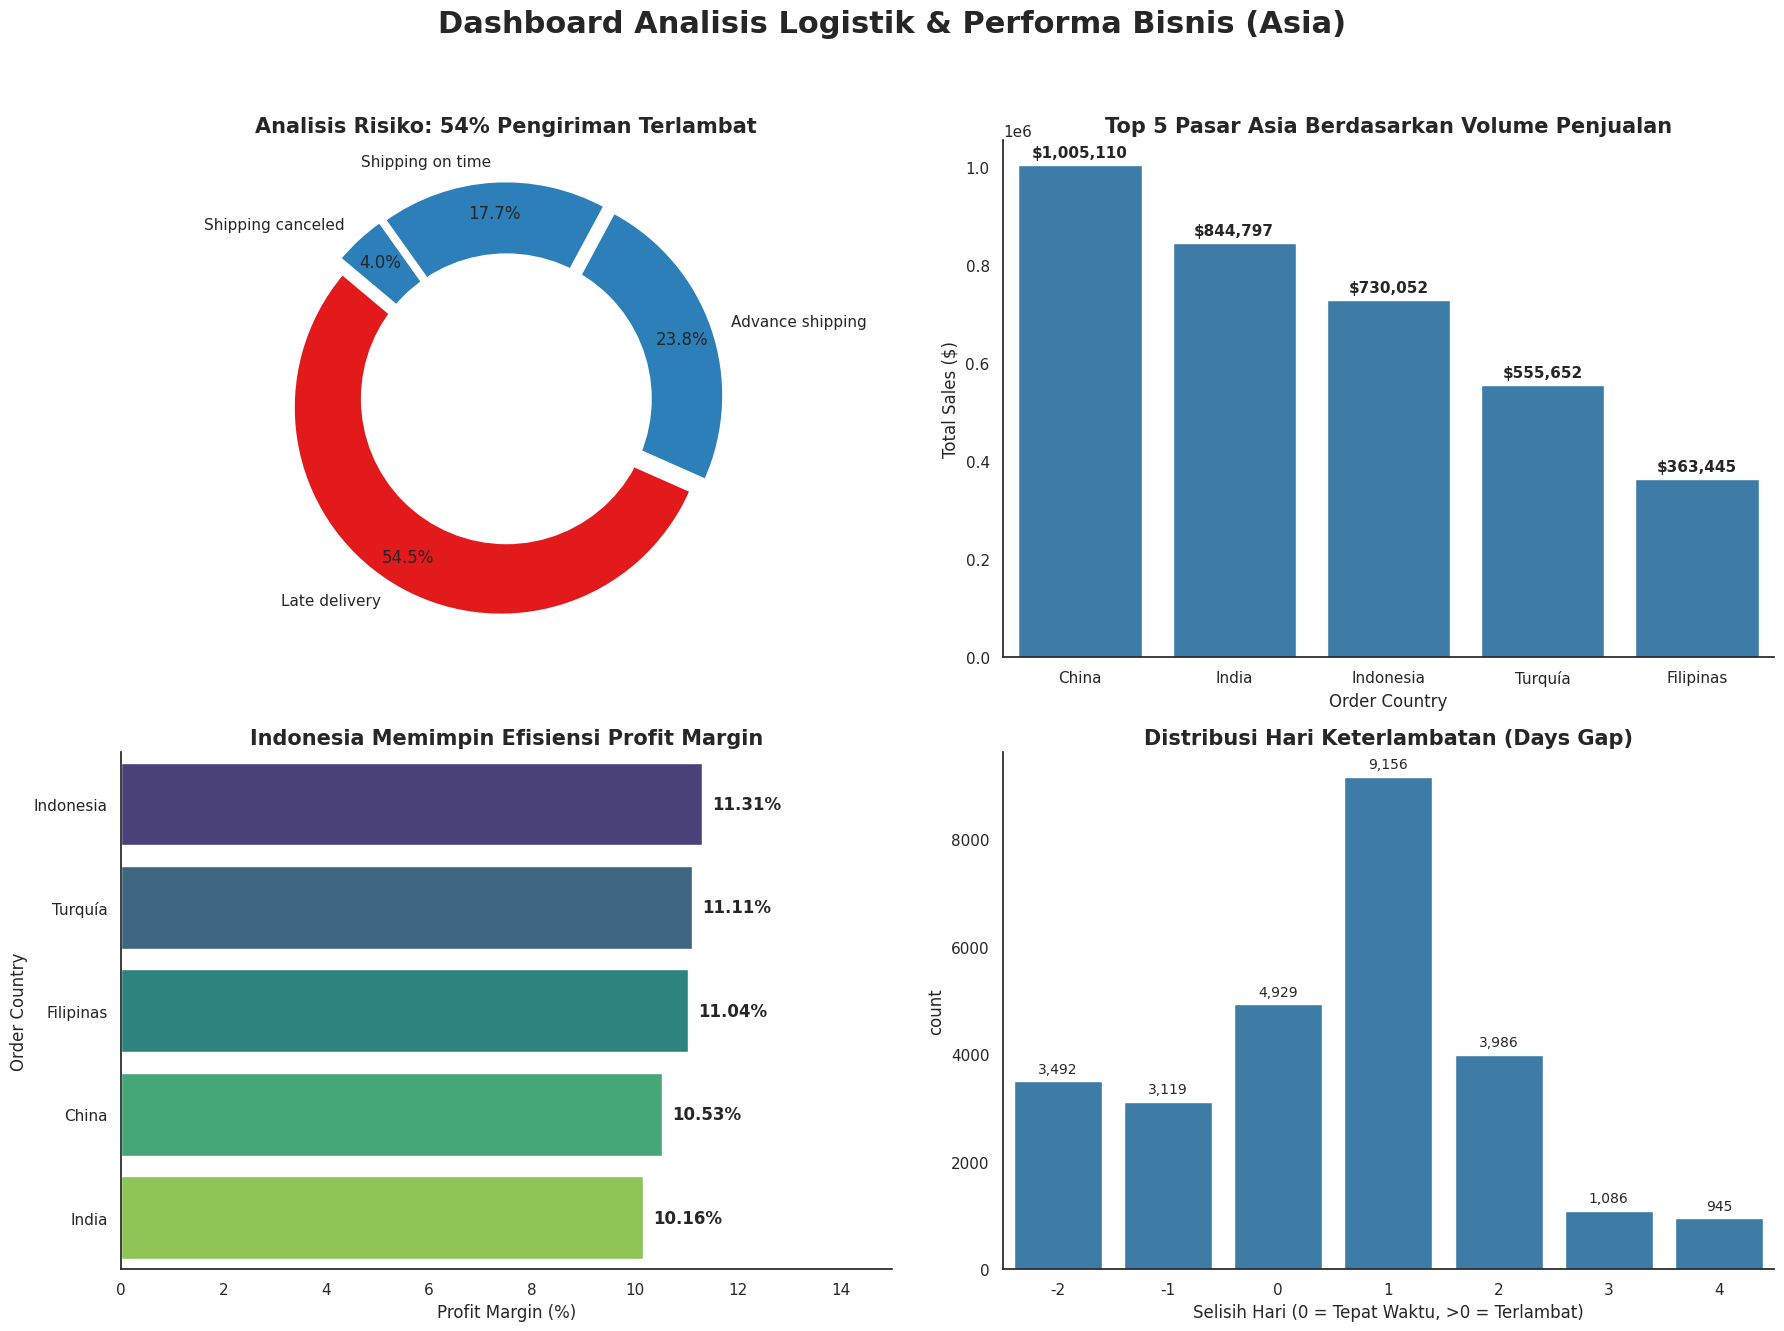

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETTING STYLE VISUALISASI (Profesional & Clean)
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'
color_blue = '#2c7fb8'  # Biru Profesional (Medical/Corporate)
color_red = '#e31a1c'   # Merah Peringatan (Risk)
color_green = '#31a354' # Hijau Keberhasilan (On-time)

# Membuat Frame untuk Dashboard (2 Baris, 2 Kolom)
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Dashboard Analisis Logistik & Performa Bisnis (Asia)', fontsize=22, fontweight='bold', y=0.98)

# ---------------------------------------------------------
# CHART 1: PROPORSI STATUS PENGIRIMAN (Donut Chart)
# ---------------------------------------------------------
status_counts = df_clean['Delivery Status'].value_counts()
colors_status = [color_red if x == 'Late delivery' else color_blue for x in status_counts.index]

axes[0, 0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
              startangle=140, colors=colors_status, pctdistance=0.85,
              explode=[0.05] * len(status_counts))
# Membuat lubang di tengah agar menjadi Donut Chart
center_circle = plt.Circle((0,0), 0.70, fc='white')
axes[0, 0].add_artist(center_circle)
axes[0, 0].set_title('Analisis Risiko: 54% Pengiriman Terlambat', fontsize=15, fontweight='bold')

# ---------------------------------------------------------
# CHART 2: TOP 5 NEGARA BERDASARKAN TOTAL SALES (Bar Chart)
# ---------------------------------------------------------
# Data sudah kita siapkan di tahap sebelumnya (top_5_negara)
top_5_plot = top_5_negara.reset_index()
sns.barplot(x='Order Country', y='Sales', data=top_5_plot, ax=axes[0, 1], color=color_blue)

# MENAMBAHKAN LABEL DATA DI ATAS BAR (Statistik Sales)
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f'${p.get_height():,.0f}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points',
                        fontsize=11, fontweight='bold')

axes[0, 1].set_title('Top 5 Pasar Asia Berdasarkan Volume Penjualan', fontsize=15, fontweight='bold')
axes[0, 1].set_ylabel('Total Sales ($)')
axes[0, 1].spines['top'].set_visible(False)
axes[0, 1].spines['right'].set_visible(False)

# ---------------------------------------------------------
# CHART 3: PERINGKAT PROFIT MARGIN PER NEGARA (Horizontal Bar)
# ---------------------------------------------------------
top_5_margin = top_5_plot.sort_values('Profit Margin (%)', ascending=False)
sns.barplot(x='Profit Margin (%)', y='Order Country', data=top_5_margin, ax=axes[1, 0], palette='viridis')

# MENAMBAHKAN LABEL DATA (Statistik Margin %)
for i, v in enumerate(top_5_margin['Profit Margin (%)']):
    axes[1, 0].text(v + 0.2, i, f'{v:.2f}%', va='center', fontweight='bold')

axes[1, 0].set_title('Indonesia Memimpin Efisiensi Profit Margin', fontsize=15, fontweight='bold')
axes[1, 0].set_xlim(0, 15) # Memberi ruang untuk label
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# ---------------------------------------------------------
# CHART 4: DISTRIBUSI KETERLAMBATAN (Shipping Gap)
# ---------------------------------------------------------
sns.countplot(x='Shipping_Gap', data=df_clean, ax=axes[1, 1], color=color_blue)

# MENAMBAHKAN LABEL DATA (Jumlah Transaksi)
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f'{int(p.get_height()):,}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points',
                        fontsize=10)

axes[1, 1].set_title('Distribusi Hari Keterlambatan (Days Gap)', fontsize=15, fontweight='bold')
axes[1, 1].set_xlabel('Selisih Hari (0 = Tepat Waktu, >0 = Terlambat)')
axes[1, 1].spines['top'].set_visible(False)
axes[1, 1].spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# Ekspor data bersih ke CSV untuk diolah di Tableau
df_clean.to_csv('Clean_Logistics_Asia_2026.csv', index=False)

from google.colab import files
files.download('Clean_Logistics_Asia_2026.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# --- SEL: MENYIMPAN DATA KE FORMAT EXCEL ---

# 1. Menentukan nama fail Excel
nama_fail = 'Clean_Logistics_Asia_2026.xlsx'

# 2. Menyimpan data bersih (df_clean) ke dalam fail Excel
# index=False digunakan agar nombor baris (indeks) tidak ikut tersimpan sebagai lajur baharu
df_clean.to_excel(nama_fail, index=False)

# 3. Mengunduh fail secara automatik ke komputer anda
from google.colab import files
files.download(nama_fail)

print("Data berjaya disimpan dan sedang diunduh dalam format Excel!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Data berjaya disimpan dan sedang diunduh dalam format Excel!
